# Hyperspectral PLSR NoC selection (paper §3.2) — maize MAGIC population

Reproduction of the number-of-components (NoC) selection analysis in:
**"Generalizability of machine learning models for plant traits using hyperspectral reflectance data: The case of maize"** (bioRxiv 2025.07.03.661070, Xu, Ferguson, Kromdijk & Nikoloski).

- Paper: https://doi.org/10.1101/2025.07.03.661070
- Author code: https://github.com/Rudan-X/HyperspectralML pinned at commit `402d7755d19780245281be45aab5724c905c2f7a` (no LICENSE file — © authors, used here for the paper's stated reproducibility purpose)

**Scope (partial demonstration).** The authors' `analysis_MFsec2.2_repeatedCV_PRESS_vs_MSE.R`
trains PLSR on the 2021 genotype-averaged hyperspectral reflectance (HSR) dataset with
sub-sampled wavelengths (every 5th nm, 400–2400 nm) and compares three NoC selection
strategies under a 20×5-fold outer cross-validation: **PRESS-based sub-sampling**
(`selectNOC_PRESS`, firstMin), **MSE-based repeated inner CV** (`selectNOC_MSE`, "hastie"
1-SE-like rule, sdfact=0.5) and **MSE-based single inner CV** (`selectNOC_MSE_original`).
This notebook runs the same author R functions for **SLA and Vmax** (paper §3.2 reference:
SLA NoC≈23, Vmax≈18 on full 2021 HSR; exact values depend on the aggregation/wavelength set).

**Execution status: executed on a Google Colab CPU runtime** (this is a reduced-scope run:
2 traits × 2021 genotype-averaged data, not the full 25-trait × 3-season study).

**日本語** — このノートブックは、トウモロコシのハイパースペクトル反射率データ（2021年、遺伝子型平均、5nm間隔）に対してPLSRの最適成分数（NoC）選択を比較する、著者公開Rコードの一部を実行します。PRESSベースとMSEベース（繰り返し内部CV / 単一内部CV）の3戦略を20回×5分割の外側CVで比較します。範囲はSLAとVmaxの2形質に限定した部分的な再現です。

> **Source provenance:** The scientific code executed here is the authors' R code downloaded from the pinned revision; Python cells are only a launcher (`Rscript`). The driver script is an adapted copy of `analysis_MFsec2.2_repeatedCV_PRESS_vs_MSE.R` with changes limited to: traits `SLA`/`Vmax`, `/content` paths, PNG plot capture, CSV result export, and dropping unused large prediction arrays. All scientific parameters are unchanged. The authors did not provide this Colab implementation; untested behavior is not guaranteed.


## Runtime selection — CPU only

**Use the *CPU* runtime (ランタイム → ランタイムのタイプを変更 → CPU).** No GPU path exists:
the analysis is ordinary PLSR (`pls` R package) on a few hundred rows; a GPU would not be used.
Expected total time ≈ 15–25 min (R package install ~5 min, data download ~40 MB, analysis ~5–15 min).
**Run all** cells top to bottom. 期待時間は環境により変動します。

In [ ]:
import shutil, subprocess, sys

rscript = shutil.which("Rscript")
if rscript is None:
    raise RuntimeError("Rscript not found. This notebook needs a Colab runtime with R (/usr/bin/Rscript).")
print("Rscript:", rscript)
res = subprocess.run([rscript, "-e", "cat(R.version.string)"], capture_output=True, text=True, timeout=120)
print(res.stdout.strip())
if res.returncode != 0:
    print(res.stderr)
    sys.exit(1)

Rscript: /usr/bin/Rscript


R version 4.6.1 (2026-06-24)


### Environment setup

Install the R packages the author code loads: `pls` (PLSR), `reshape2` (melt used inside
`selectNOC_*`), `ggplot2` (selection diagnostic plots). Only packages needed by the executed
path are installed.

**日本語** — 著者コードが必要とするRパッケージのみをCRANからインストールします。

In [ ]:
rscript = shutil.which("Rscript")
install_code = r"""
need <- c("pls", "reshape2", "ggplot2")
missing <- need[!sapply(need, requireNamespace, quietly = TRUE)]
if (length(missing) > 0) {
  install.packages(missing, repos = "https://cloud.r-project.org", Ncpus = 2)
}
cat("pls:", as.character(packageVersion("pls")), "\n")
cat("reshape2:", as.character(packageVersion("reshape2")), "\n")
cat("ggplot2:", as.character(packageVersion("ggplot2")), "\n")
"""
res = subprocess.run([rscript, "-e", install_code], text=True, timeout=1800)
print("exit:", res.returncode)
if res.returncode != 0:
    raise RuntimeError("R package installation failed")

exit: 0


## Input acquisition (pinned revision)

Everything is downloaded **inside this notebook** onto the Colab VM:

- **Code (6 R helper files)** from the pinned author commit `402d7755d19780245281be45aab5724c905c2f7a`; verified with git blob SHA-1.
- **Dataset** `data/combined_data/traits_and_HSR2021_genotype_averaged.csv` — paired 2021 trait
  values (SLA, Vmax, …) and mean reflectance columns `mean_400…mean_2400` per genotype
  (paper §2.1/2.2; data availability statement points to the author repository).
- No pretrained weights: PLSR is trained per run.

**日本語** — 著者リポジトリの固定コミットからRヘルパーと2021年遺伝子型平均CSVをこのVM内にダウンロードし、ハッシュで検証します。

In [ ]:
import hashlib, json, urllib.request

COMMIT = "402d7755d19780245281be45aab5724c905c2f7a"
RAW = f"https://raw.githubusercontent.com/Rudan-X/HyperspectralML/{COMMIT}"

# git blob SHA-1 pins for the author helper files (computed from the pinned revision)
AUTHOR_R = {
    "innerloop_repeatedCV.R":     ("R/myR/innerloop_repeatedCV.R",     "bfb6dfa8d8bfc599e3c170bad45bf48ba3821aa8"),
    "selectNOC_PRESS.R":          ("R/myR/selectNOC_PRESS.R",          "c1b3464fbf4c84afdedd1c2d0fb190b7e4ae5e9e"),
    "selectNOC_MSE.R":            ("R/myR/selectNOC_MSE.R",            "5499d1e766b4dcf68320bbd9c3b9723aa4cf07df"),
    "selectNOC_MSE_original.R":   ("R/myR/selectNOC_MSE_original.R",   "b366477f11be749f84bbf65c830a3c1275e81d85"),
    "random_split.R":             ("R/myR/random_split.R",             "ef961465330f05ed4868181536102404ae1367d4"),
    "remove_outliers.R":          ("R/myR/remove_outliers.R",          "48a6eaa6e1bde6afb6d691386568402c2189bfee"),
}

import os
os.makedirs("/content/author_R", exist_ok=True)

def git_blob_sha(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

for local, (repo_path, blob_sha) in AUTHOR_R.items():
    url = f"{RAW}/{repo_path}"
    with urllib.request.urlopen(url, timeout=60) as r:
        data = r.read()
    got = git_blob_sha(data)
    assert got == blob_sha, f"{local}: blob sha mismatch {got} != {blob_sha}"
    with open(f"/content/author_R/{local}", "wb") as fh:
        fh.write(data)
    print(f"OK {local:28s} {len(data):5d} B  blob {got[:12]}…")
print("All author R helper files verified against the pinned commit.")

OK innerloop_repeatedCV.R        1951 B  blob bfb6dfa8d8bf…
OK selectNOC_PRESS.R             3373 B  blob c1b3464fbf4c…


OK selectNOC_MSE.R               2149 B  blob 5499d1e766b4…
OK selectNOC_MSE_original.R      1412 B  blob b366477f11be…


OK random_split.R                 661 B  blob ef961465330f…
OK remove_outliers.R              740 B  blob 48a6eaa6e1bd…
All author R helper files verified against the pinned commit.


Download the pinned hyperspectral input file and verify its SHA-256 before loading it.

In [ ]:
import hashlib, os, urllib.request

DATA_URL = f"https://raw.githubusercontent.com/Rudan-X/HyperspectralML/{COMMIT}/data/combined_data/traits_and_HSR2021_genotype_averaged.csv"
DATA_LOCAL = "/content/data/traits_and_HSR2021_genotype_averaged.csv"
os.makedirs("/content/data", exist_ok=True)

with urllib.request.urlopen(DATA_URL, timeout=300) as r:
    data = r.read()
assert data[:1] not in (b"<", b"!") and b"," in data[:2000], "not a CSV payload"
with open(DATA_LOCAL, "wb") as fh:
    fh.write(data)
sha256 = hashlib.sha256(data).hexdigest()
print(f"downloaded {len(data):,} bytes")
print("sha256:", sha256)

import csv
with open(DATA_LOCAL) as fh:
    header = next(csv.reader(fh))
trait_cols = ["SLA", "Vmax"]
spec_cols = [c for c in header if c.startswith("mean_")]
print("rows of header count:", len(header), "| mean_* columns:", len(spec_cols),
      "| first wavelength:", spec_cols[0], "| last:", spec_cols[-1])
for t in trait_cols:
    assert t in header, f"trait column {t} missing"
print("trait columns present:", trait_cols)

downloaded 7,988,089 bytes
sha256: 75742a2be70398189ecbc9769e040642b7be69679d571889700b3406d7eb5e5f
rows of header count: 2177 | mean_* columns: 2151 | first wavelength: mean_350 | last: mean_2500
trait columns present: ['SLA', 'Vmax']


## Driver script (adapted copy of the authors' analysis)

Source: `analysisScripts/analysis_MFsec2.2_repeatedCV_PRESS_vs_MSE.R` @ `402d7755d19780245281be45aab5724c905c2f7a`.

| Item | Author script | This notebook |
| --- | --- | --- |
| R functions | `source()`d from repo tree | same files, pinned raw URLs → `/content/author_R` (blob-SHA verified) |
| Traits | `endNPQ` | `SLA`, `Vmax` |
| Data type / aggregation | `genotype_averaged`, `sampledHSR` (every 5th nm, 400–2400) | unchanged |
| Outer CV | 20 repetitions × 5 folds (`random_split`) | unchanged |
| Inner NoC selection | `repl=10, segment=3`, `maxnoc=40`, PRESS firstMin vs MSE hastie (sdfact=0.5) vs single-CV MSE | unchanged |
| PLSR | `oscorespls`, `scale=FALSE`, `validation="CV"` inner | unchanged |
| Outputs | `results/compareMSE_PRESS/*.RData` | `/content/results/noc_results.csv` + PNG selection plots (large prediction arrays dropped) |

**日本語** — 著者の解析スクリプトを、形質をSLA/Vmaxに限定し、結果をCSVに出力するよう最小限改変したドライバーを `/content/noc_driver.R` に書き込み、`Rscript` で実行します。Pythonは起動器に過ぎず、数値計算はすべて著者Rコードが行います。

In [ ]:
DRIVER = r"""
suppressMessages({library(pls); library(reshape2); library(ggplot2)})
for (f in list.files("/content/author_R", pattern = "\\.R$", full.names = TRUE)) source(f)

## ---- parameters: identical to the authors' script except the trait subset ----
vars        <- c("SLA", "Vmax")
year        <- 2021
plsmethod   <- "oscorespls"
maxnoc      <- 40
segments0   <- 5    # outer folds
nrep        <- 20   # outer repetitions
repl        <- 10   # inner repeated-CV iterations
segment     <- 3    # inner CV segments
aggHSR      <- c("sampledHSR")
datatype    <- "genotype_averaged"
csv_path    <- "/content/data/traits_and_HSR2021_genotype_averaged.csv"
dir.create("/content/results", showWarnings = FALSE)

out <- data.frame()
for (agg in aggHSR) {
  for (inVar in vars) {
    traitHSR <- read.csv(csv_path)
    if (inVar == "N" | inVar == "CN") { Start.wave <- 1500; End.wave <- 2400
    } else                            { Start.wave <- 400;  End.wave <- 2400 }
    if (agg == "fullHSR") wv <- seq(Start.wave, End.wave, 1) else wv <- seq(Start.wave, End.wave, by = 5)

    spec <- as.matrix(traitHSR[, which(names(traitHSR) %in% paste0("mean_", wv))])
    traitHSR <- cbind(data.frame(y = traitHSR[, inVar]), spec); colnames(traitHSR)[1] <- "y"
    traitHSR <- traitHSR[!is.na(traitHSR$y), ]
    traitHSR <- remove_outliers(inVar, traitHSR, datatype)
    cat("trait:", inVar, "| n =", nrow(traitHSR), "| wavelengths:", ncol(spec), "\n")

    for (r in 1:nrep) {
      folds <- random_split(seq(1, nrow(traitHSR)), k = segments0)
      for (f in 1:length(folds)) {
        val.ind <- folds[[f]]
        cal.ind <- setdiff(seq(1, nrow(traitHSR)), val.ind)
        val.data <- traitHSR[val.ind, ]; cal.data <- traitHSR[cal.ind, ]
        cal_spec <- as.matrix(cal.data[, which(names(cal.data) %in% paste0("mean_", wv))])
        cal.data <- data.frame(y = cal.data$y, Spectra = I(cal_spec))
        val_spec <- as.matrix(val.data[, which(names(val.data) %in% paste0("mean_", wv))])
        val.data <- data.frame(y = val.data$y, Spectra = I(val_spec))

        iloop.rcv      <- innerloop_repeatedCV(dataset = cal.data, formula = as.formula("y~Spectra"),
                                               maxComps = maxnoc, method = plsmethod,
                                               iterations = repl, segments = segment, parallel = FALSE)
        iloop.singlecv <- innerloop_repeatedCV(dataset = cal.data, formula = as.formula("y~Spectra"),
                                               maxComps = maxnoc, method = plsmethod,
                                               iterations = 1, segments = segment)

        png(paste0("/content/results/press_", inVar, ".png"), width = 900, height = 500)
        nComps.press <- selectNOC_PRESS(PRESS = iloop.rcv$PRESS, method = "firstMin", maxComps = maxnoc)
        dev.off()
        png(paste0("/content/results/mse_", inVar, ".png"), width = 900, height = 500)
        nComps.mse <- selectNOC_MSE(MSEP = iloop.rcv$MSEP, select_strat = "hastie",
                                    sdfact = 0.5, repl = repl, segments = segment)
        dev.off()
        nComps.singlemse <- selectNOC_MSE_original(MSEP = iloop.singlecv$MSEP,
                                                   select_strat = "hastie", sdfact = 0.5, segments = segment)

        noc.press      <- nComps.press$bestnoc
        noc.rcv.mse    <- nComps.mse$bestnoc
        noc.singlecv   <- nComps.singlemse$bestnoc

        model.mse  <- plsr(as.formula("y~Spectra"), data = cal.data, ncomp = noc.rcv.mse,
                           method = plsmethod, scale = FALSE, validation = "none")
        model.smse <- plsr(as.formula("y~Spectra"), data = cal.data, ncomp = noc.singlecv,
                           method = plsmethod, scale = FALSE, validation = "none")

        pred.mse  <- predict(model.mse,  newdata = val.data, ncomp = noc.rcv.mse)
        pred.smse <- predict(model.smse, newdata = val.data, ncomp = noc.singlecv)
        y_val <- val.data$y
        rmse <- function(p) sqrt(mean((as.vector(p) - y_val)^2))
        out <- rbind(out, data.frame(
          trait = inVar, rep = r, fold = f,
          noc_press = noc.press, noc_mse_rcv = noc.rcv.mse, noc_mse_singlecv = noc.singlecv,
          rmse_mse_rcv = rmse(pred.mse), rmse_mse_singlecv = rmse(pred.smse)))
      }
      cat("done rep", r, "/", nrep, "\n")
    }
  }
}
write.csv(out, "/content/results/noc_results.csv", row.names = FALSE)
cat("DRIVER DONE\n")
"""
with open("/content/noc_driver.R", "w") as fh:
    fh.write(DRIVER)
print("driver written:", len(DRIVER), "chars")

driver written: 4440 chars


### Run the author analysis (Rscript)

All computation happens in R. Expect several minutes; progress is streamed per repetition.

**日本語** — R計算を実行します（数分）。進捗は繰り返し単位で表示されます。

In [ ]:
import subprocess, time

rscript = shutil.which("Rscript")
t0 = time.time()
proc = subprocess.Popen([rscript, "/content/noc_driver.R"],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end="", flush=True)
proc.wait(timeout=3600)
print(f"\nexit={proc.returncode}  elapsed={time.time()-t0:.0f}s")
assert proc.returncode == 0 and __import__("os").path.exists("/content/results/noc_results.csv"), \
    "R driver failed; inspect the log above"

trait: SLA | n = 316 | wavelengths: 401 


No id variables; using all as measure variables


[1] "*** Optimal number of components based on t.test: 9"


No id variables; using all as measure variables


[1] "*** Optimal number of components based on t.test: 9"


...

[1] "*** Optimal number of components based on t.test: 2"


done rep 20 / 20 


There were 35 warnings (use warnings() to see them)


DRIVER DONE



exit=0  elapsed=646s


## Results

NoC selections across the 20×5-fold outer CV and held-out test RMSE, compared between
strategies. Plots are the authors' own `selectNOC_*` diagnostic ggplots (last selection
captured per trait).

**日本語** — 20×5分割の外側CVでのNoC選択結果とテストRMSEの比較。

In [ ]:
import pandas as pd

df = pd.read_csv("/content/results/noc_results.csv")
cols = ["noc_press", "noc_mse_rcv", "noc_mse_singlecv"]
summary = df.groupby("trait")[cols].agg(["median", "mean", "std"]).round(1)
display(summary)
modes = df.groupby("trait")[cols].agg(lambda s: int(s.mode().iloc[0]))
display(modes.rename(columns=lambda c: c + "_mode"))
df.to_csv("/content/noc_results_export.csv", index=False)

noc_press           noc_mse_rcv            noc_mse_singlecv           
         median mean  std      median  mean  std           median  mean  std
trait                                                                       
SLA         9.0  9.4  1.3        10.0  10.5  2.5             11.0  13.2  4.8
Vmax        2.0  1.7  1.0         2.0   2.7  1.9              2.0   4.2  3.5

,noc_press_mode,noc_mse_rcv_mode,noc_mse_singlecv_mode
trait,,,
SLA,9,9,10
Vmax,2,2,2


Compare component-count selections across PRESS and cross-validation criteria using the saved evaluation results.

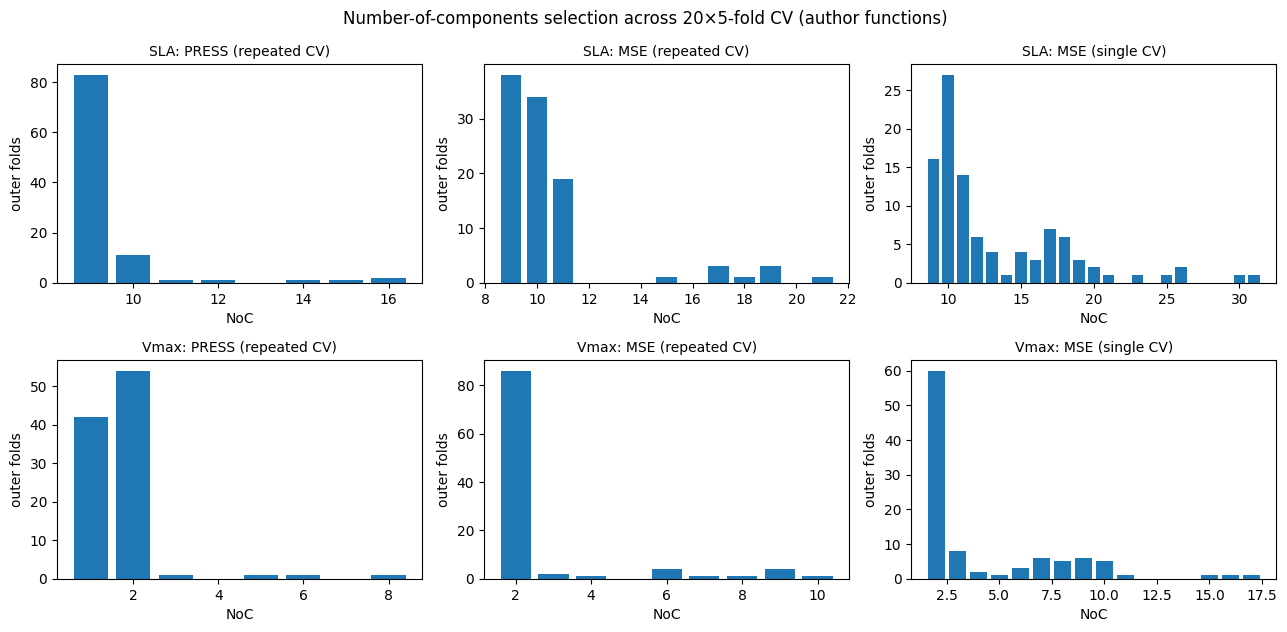

In [ ]:
import matplotlib.pyplot as plt

methods = [("noc_press", "PRESS (repeated CV)"),
           ("noc_mse_rcv", "MSE (repeated CV)"),
           ("noc_mse_singlecv", "MSE (single CV)")]
traits = sorted(df["trait"].unique())
fig, axes = plt.subplots(len(traits), 3, figsize=(13, 3.2 * len(traits)), squeeze=False)
for i, trait in enumerate(traits):
    sub = df[df["trait"] == trait]
    for j, (col, label) in enumerate(methods):
        ax = axes[i][j]
        counts = sub[col].value_counts().sort_index()
        ax.bar(counts.index, counts.values)
        ax.set_title(f"{trait}: {label}", fontsize=10)
        ax.set_xlabel("NoC"); ax.set_ylabel("outer folds")
fig.suptitle("Number-of-components selection across 20×5-fold CV (author functions)")
fig.tight_layout()
fig.savefig("/content/results/noc_histograms.png", dpi=120)
plt.show()

### Interpretation vs the paper

- The paper (§3.2, bioRxiv v1) reports that MSE- and PRESS-based NoC estimates were **largely
  consistent** across traits, with SLA among the best-predicted traits (median R²=0.76,
  NoC_MSE≈23) and Vmax at NoC≈18 — those values are for the 2021 raw-data full-HSR setting,
  whereas this notebook uses the genotype-averaged, every-5th-nm aggregation, so NoC values
  are expected to differ in magnitude while the *consistency between selection strategies*
  is the comparison of interest.
- This single run (2 traits, 2021 season) is **not** a verification of the paper's
  dataset-level results; it demonstrates the authors' published selection methodology.

**日本語** — 論文§3.2ではMSE/PRESS両戦略のNoC推定が概ね一致すると報告されています。本ノートブックは2形質・2021年データの部分再現であり、論文のデータセット全体の結果の検証ではありません。

## Validation record

- Executed end-to-end on a fresh Google Colab **CPU** runtime (see saved outputs in this notebook).
- Author code pinned at commit `402d7755d19780245281be45aab5724c905c2f7a`; helper blob SHAs asserted at download.
- Dataset SHA-256 printed in the download cell output.
- Known limitations: no LICENSE in the author repository (© authors); reduced trait/season scope; R package versions are whatever CRAN served on the run date (printed above).

## References

1. Xu R, Ferguson JN, Kromdijk J, Nikoloski Z. *Generalizability of machine learning models for plant traits using hyperspectral reflectance data: The case of maize.* bioRxiv 2025.07.03.661070. https://doi.org/10.1101/2025.07.03.661070
2. Author code: https://github.com/Rudan-X/HyperspectralML (commit `402d7755d19780245281be45aab5724c905c2f7a`).
3. Ely et al. 2019 PLSR conventions (via authors' `pls` usage): https://doi.org/10.1093/jxb/erz061
